In [ ]:
"""
- Initialize population
- Initialize weapon access points
- sample gathering size
"""
import numpy as np
import matplotlib.pyplot as plt

'\n- Initialize population\n- Initialize weapon access points\n- sample gathering size\n'

In [4]:
rng = np.random.default_rng(seed=None)
population_density = 12000
weapon_density = 8000

"""
Params: 
    access_coef
    walk_radius
    atrisk_gathering_rate
    weibull_scale
    weibull_shape
"""

def sample_event(population_density, weapon_density, population_grid, access_grid, walk_grid, rng): 
    access_coef = 1e-6
    population_grid.fill(population_density)
    access_count = rng.poisson(access_coef*weapon_density*population_grid.size)
    access_points = rng.choice(population_grid.size, access_count, p=population_grid.flatten() / population_grid.sum())
    access_grid.fill(0)
    access_grid.reshape((-1,))[access_points] = 1

    walk_radius = 200
    random_walk = rng.integers(-1, 2, (walk_radius, 2))
    random_walk = np.cumsum(random_walk, axis=0) % population_grid.shape[0]
    weapon_access = np.any(access_grid[random_walk[:, 0], random_walk[:, 1]])
    if(not weapon_access):
        return 0
    
    walk_grid.fill(0)
    walk_grid[random_walk[:, 0], random_walk[:, 1]] = 1
    atrisk_gathering_rate = 1e-6
    population_encounters = np.sum(walk_grid*population_grid)
    location_count = rng.poisson(population_encounters*atrisk_gathering_rate)
    if(location_count <= 0):
        return 0
    
    loc_gathering_size = 10*rng.weibull(0.4, (location_count,))
    gathering_size = np.max(loc_gathering_size)
    return np.random.uniform(0, gathering_size)

def sample_n(n, rng, sim_params):
    population_grid = np.zeros((50, 50))
    access_grid = np.zeros_like(population_grid)
    walk_grid = np.zeros_like(population_grid)
    sims = []
    for i in range(n):
        sims.append(sample_event(sim_params["population_density"], sim_params["weapon_density"], 
                                 population_grid, access_grid, walk_grid, rng))
    return np.array(sims)

In [5]:
events = sample_n(int(1e5), rng, {"population_density": 1.2e4, "weapon_density": 8.0e3})

NameError: name 'sample_n' is not defined

In [4]:
event_counts = np.array([sample_event(population_density, weapon_density, population_grid, access_grid, walk_grid, rng) for _ in range(int(1e5))])
event_counts.sort()

In [ ]:
propensity = 1e-7 #Event / year / person


In [1]:
from scipy.stats import ecdf
res = ecdf(event_counts)
plt.plot(res.cdf.quantiles, res.cdf.probabilities)

NameError: name 'event_counts' is not defined

In [ ]:
from scipy.stats import ecdf
def grenander_pdf(x, data):
    res = ecdf(data)
    quantiles = res.cdf.quantiles
    prob = res.cdf.probabilities
    quantiles = np.concatenate([quantiles, np.array([np.inf])])
    prob = np.concatenate([prob, np.array([1])])

    qind = np.searchsorted(quantiles, x)
    pdf = (prob[qind+1]-prob[qind])/(quantiles[qind+1] - quantiles[qind])
    return pdf


(0.0, 1.0)

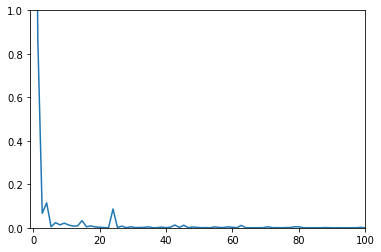

In [11]:
x = np.linspace(0.001, 2000, 1500)
pdf_est = grenander_pdf(x, event_counts)
plt.plot(x, pdf_est)
plt.xlim(-1, 100)
plt.ylim(0, 1)

In [ ]:
p

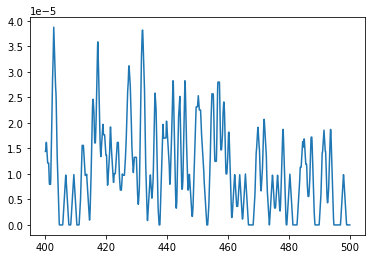

1.0 1.0


In [ ]:
def kernel_density(x, alpha=1):
    return np.maximum(1-np.abs(x*alpha), 0)*alpha
def kernel_cdf(x, alpha=1):
    x = x*alpha
    return ((x > -1) & (x < 0))*0.5*(x+1)*(x+1) + ((x >= 0) & (x < 1))*(1-0.5*(1-x)*(1-x)) + (x >= 1)
def kernel_pdf_estimate(x, data, kernel_density):
    return np.mean(kernel_density(x.reshape((1, -1))-data.reshape((-1, 1))), axis=0)
def kernel_cdf_estimate(x, data, kernel_cdf):
    return np.mean(kernel_cdf(x.reshape((1, -1))-data.reshape((-1, 1))), axis=0)

x = np.linspace(400, 500, 1500)
# plt.plot(x, kernel_density(x-12, alpha=0.1)); plt.plot(x, kernel_cdf(x-12, alpha=0.1))
plt.plot(x, kernel_pdf_estimate(x, event_counts, lambda x: kernel_density(x, alpha=1)))
# plt.plot(x, kernel_cdf_estimate(x, event_counts, lambda x: kernel_cdf(x, alpha=1)))
plt.show()

In [8]:
from sklearn.neighbors import KernelDensity
import numpy as np

counts = np.sort(np.array(event_counts))
counts

array([   0.        ,    0.        ,    0.        , ...,  766.24928879,
       1017.44752956, 1454.57192253])

In [7]:
event_counts = [sample_event(population_density, weapon_density, population_grid, access_grid, walk_grid, rng) for _ in range(int(1e4))]
d = {}
for pop_dens in np.linspace(0, 30000, 500):
    event_counts = [sample_event(population_density, weapon_density, population_grid, access_grid, walk_grid, rng) for _ in range(int(1e4))]
    d[pop_dens] = event_counts

In [4]:
propensity = 1e-6 #Dangerous person / person / year
dataset = None #county: [(time, fatalities)]

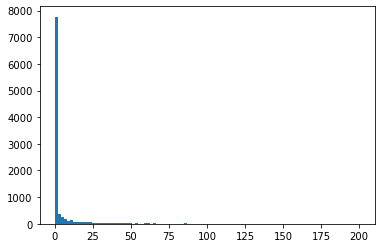

In [5]:
plt.hist(event_counts, bins=np.linspace(0, 200, 100))
plt.show()

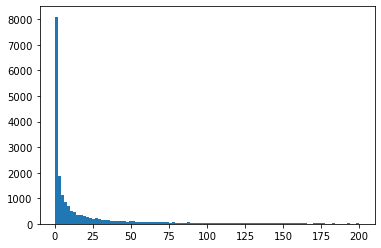

In [15]:
loc_gathering_size = 10*rng.weibull(0.4, (20000,))
plt.hist(loc_gathering_size, bins=np.linspace(0, 200, 100))
plt.show()

In [ ]:
def init_background_density(board, n, rng):
    board = np.copy(board)
    return board